In [11]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

   Student_ID  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0        1048   22  Female  B.Tech    ECE  6.29            0         3   
1       37820   20  Female     BCA    ECE  6.05            1         4   
2       49668   22    Male     MCA     ME  7.22            1         4   
3       19467   22    Male     MCA     ME  7.78            2         4   
4       23094   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

In [6]:
print(df["Placement_Status"].value_counts())

Placement_Status
Not Placed    28688
Placed        16312
Name: count, dtype: int64


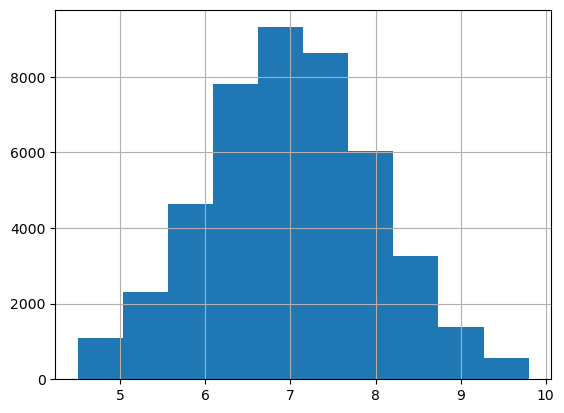

In [7]:
import matplotlib.pyplot as plt

df["CGPA"].hist()
plt.show()

In [8]:
df.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [10]:
df.fillna(0, inplace=True)


In [11]:
df.drop_duplicates(inplace=True)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

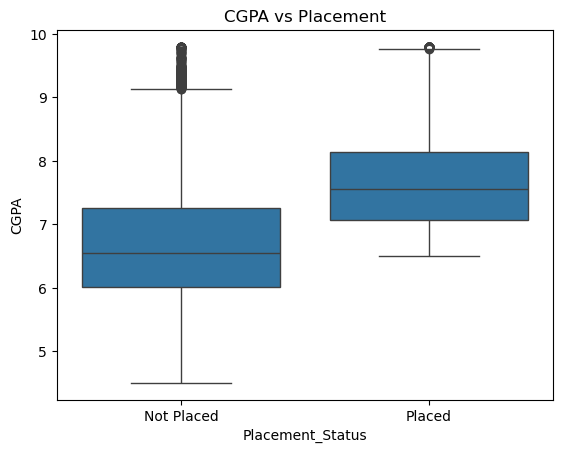

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Placement_Status", y="CGPA", data=df)
plt.title("CGPA vs Placement")
plt.show()

In [19]:
print(df.dtypes)

Student_ID                int64
Age                       int64
Gender                    int64
Degree                   object
Branch                   object
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
Placement_Status         object
dtype: object


In [20]:
print(df.select_dtypes(include=['object']).columns)

Index(['Degree', 'Branch', 'Placement_Status'], dtype='object')


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Degree'] = le.fit_transform(df['Degree'])
df['Branch'] = le.fit_transform(df['Branch'])
df['Placement_Status'] = le.fit_transform(df['Placement_Status'])

In [22]:
X = df.drop('Placement_Status', axis=1)
y = df['Placement_Status']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [26]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
9   Communication_Skills    0.309098
13              Backlogs    0.173696
5                   CGPA    0.161831
7               Projects    0.106398
8          Coding_Skills    0.094972
12        Certifications    0.071066
10   Aptitude_Test_Score    0.061398
6            Internships    0.009340
0             Student_ID    0.004559
4                 Branch    0.002143
1                    Age    0.001907
11    Soft_Skills_Rating    0.001729
3                 Degree    0.001231
2                 Gender    0.000633


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[5709    0]
 [   0 3291]]


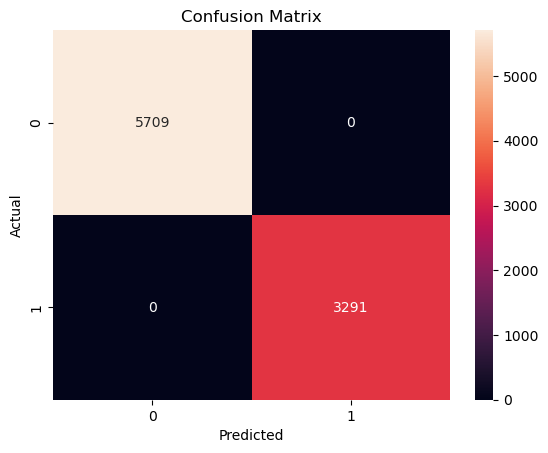

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5709
           1       1.00      1.00      1.00      3291

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
9   Communication_Skills    0.309098
13              Backlogs    0.173696
5                   CGPA    0.161831
7               Projects    0.106398
8          Coding_Skills    0.094972
12        Certifications    0.071066
10   Aptitude_Test_Score    0.061398
6            Internships    0.009340
0             Student_ID    0.004559
4                 Branch    0.002143
1                    Age    0.001907
11    Soft_Skills_Rating    0.001729
3                 Degree    0.001231
2                 Gender    0.000633


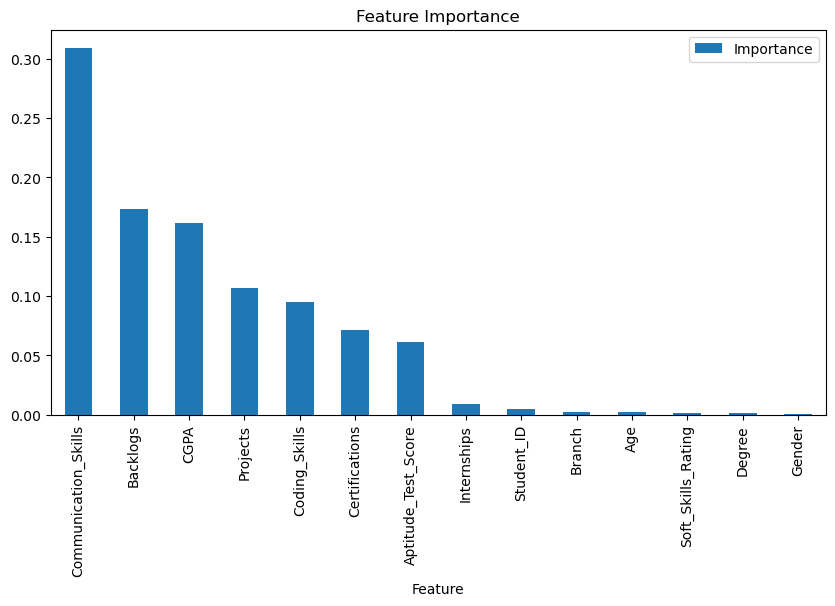

In [31]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

In [33]:
print(X.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']


In [35]:
print(X.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']


In [36]:
print(len(X.columns))

14


In [37]:
sample = X.iloc[[0]]

print(sample)

result = model.predict(sample)

print("Prediction:", result)

   Student_ID  Age  Gender  Degree  Branch  CGPA  Internships  Projects  \
0        1048   22       0       1       2  6.29            0         3   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   

   Soft_Skills_Rating  Certifications  Backlogs  
0                   5               1         3  
Prediction: [0]


In [38]:
sample = X.iloc[[0]]

print(sample)

result = model.predict(sample)

print("Prediction:", result)

   Student_ID  Age  Gender  Degree  Branch  CGPA  Internships  Projects  \
0        1048   22       0       1       2  6.29            0         3   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   

   Soft_Skills_Rating  Certifications  Backlogs  
0                   5               1         3  
Prediction: [0]


In [39]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
9   Communication_Skills    0.309098
13              Backlogs    0.173696
5                   CGPA    0.161831
7               Projects    0.106398
8          Coding_Skills    0.094972
12        Certifications    0.071066
10   Aptitude_Test_Score    0.061398
6            Internships    0.009340
0             Student_ID    0.004559
4                 Branch    0.002143


In [40]:
model.predict(sample)

array([0])

In [41]:
model.predict_proba(sample)

array([[1., 0.]])

In [42]:
prob = model.predict_proba(sample)

print(prob)

[[1. 0.]]


In [43]:
from sklearn.ensemble import RandomForestRegressor

In [45]:
required_skills = {
    "Data Scientist": [
        "Python",
        "SQL",
        "Machine Learning",
        "Statistics",
        "Power BI"
    ]
}

In [46]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [49]:
with open("app.py", "w") as f:
    f.write("""
import streamlit as st

st.title("AI Career Success Predictor")
st.write("Welcome!")
""")

In [50]:
import os
print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.android', '.bash_history', '.codex', '.conda', '.continuum', '.copilot', '.emulator_console_auth_token', '.git', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.virtual_documents', '.vscode', '.vscode-shared', '18.html', 'abrar.18.html', 'alameen-portfolio', 'AndroidStudioProjects', 'app.py', 'AppData', 'Apple', 'Application Data', 'Contacts', 'Cookies', 'cred-clone', 'cryptography.c', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'my-portfolio', 'NetHood', 'node_modules', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{3987c926-28ff-11f0-969c-e83308815e10}.TM.blf', 'NTUSER.DAT{3987c926-28ff-11f0-969c-e83308815e10}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{3987c926-28ff-11f0-969c-e83308815e10}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'package-lock.json', 'package.json', 'portfolio', 'premium-s

In [3]:
import pandas as pd

df = pd.read_csv("train.csv")

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Degree'] = le.fit_transform(df['Degree'])
df['Branch'] = le.fit_transform(df['Branch'])
df['Placement_Status'] = le.fit_transform(df['Placement_Status'])

In [5]:
X = df.drop("Placement_Status", axis=1)
y = df["Placement_Status"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [9]:
import joblib

joblib.dump(model, "placement_model.pkl")

print("Model Saved!")

Model Saved!


In [10]:
import os
print(os.getcwd())


C:\Users\AlAmeen\project 1


In [12]:
print(X.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']


In [13]:
print(X.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']


In [14]:
print(model.classes_)

[0 1]


In [15]:
print(X.columns.tolist())
print(model.classes_)

['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']
[0 1]


In [16]:
print(X.columns.tolist())


['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']


In [17]:
print(X.columns.tolist())

['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']


In [18]:
print(df['Gender'].unique())
print(df['Degree'].unique())
print(df['Branch'].unique())

['Female' 'Male']
['B.Tech' 'BCA' 'MCA' 'B.Sc']
['ECE' 'ME' 'Civil' 'CSE' 'IT']


In [19]:
from sklearn.preprocessing import LabelEncoder

print(df[['Gender','Degree','Branch']].head())

   Gender  Degree Branch
0  Female  B.Tech    ECE
1  Female     BCA    ECE
2    Male     MCA     ME
3    Male     MCA     ME
4  Female  B.Tech     ME


In [20]:
print(df['Placement_Status'].unique())

['Not Placed' 'Placed']


In [21]:
prediction = model.predict(input_df)

NameError: name 'input_df' is not defined

In [22]:
print(df['Gender'].unique())

['Female' 'Male']


In [23]:
print(df['Degree'].unique())

['B.Tech' 'BCA' 'MCA' 'B.Sc']


In [24]:
print(df['Branch'].unique())

['ECE' 'ME' 'Civil' 'CSE' 'IT']


In [25]:
print(df['Placement_Status'].unique())

['Not Placed' 'Placed']


In [26]:
prediction = model.predict(input_df)
probability = model.predict_proba(input_df)

NameError: name 'input_df' is not defined

In [27]:
print(df[['Gender','Degree','Branch']].head(10))

   Gender  Degree Branch
0  Female  B.Tech    ECE
1  Female     BCA    ECE
2    Male     MCA     ME
3    Male     MCA     ME
4  Female  B.Tech     ME
5    Male     BCA    ECE
6    Male     MCA    ECE
7    Male  B.Tech     ME
8    Male     BCA  Civil
9    Male    B.Sc     ME


In [28]:
print(df[['Gender','Degree','Branch']].head(10))

   Gender  Degree Branch
0  Female  B.Tech    ECE
1  Female     BCA    ECE
2    Male     MCA     ME
3    Male     MCA     ME
4  Female  B.Tech     ME
5    Male     BCA    ECE
6    Male     MCA    ECE
7    Male  B.Tech     ME
8    Male     BCA  Civil
9    Male    B.Sc     ME


In [29]:
import joblib

model = joblib.load("placement_model.pkl")
print(model)

RandomForestClassifier(random_state=42)


In [30]:
print(df[['Gender','Degree','Branch']].head(10))

   Gender  Degree Branch
0  Female  B.Tech    ECE
1  Female     BCA    ECE
2    Male     MCA     ME
3    Male     MCA     ME
4  Female  B.Tech     ME
5    Male     BCA    ECE
6    Male     MCA    ECE
7    Male  B.Tech     ME
8    Male     BCA  Civil
9    Male    B.Sc     ME


In [31]:
In [ ]:

SyntaxError: invalid syntax (1689995131.py, line 1)

In [32]:
print(df[['Gender','Degree','Branch']].head(10))

   Gender  Degree Branch
0  Female  B.Tech    ECE
1  Female     BCA    ECE
2    Male     MCA     ME
3    Male     MCA     ME
4  Female  B.Tech     ME
5    Male     BCA    ECE
6    Male     MCA    ECE
7    Male  B.Tech     ME
8    Male     BCA  Civil
9    Male    B.Sc     ME


In [33]:
print(df[['Gender','Degree','Branch']].head(20))

    Gender  Degree Branch
0   Female  B.Tech    ECE
1   Female     BCA    ECE
2     Male     MCA     ME
3     Male     MCA     ME
4   Female  B.Tech     ME
5     Male     BCA    ECE
6     Male     MCA    ECE
7     Male  B.Tech     ME
8     Male     BCA  Civil
9     Male    B.Sc     ME
10  Female     MCA  Civil
11    Male     MCA    ECE
12    Male    B.Sc    CSE
13    Male  B.Tech    ECE
14  Female     MCA    ECE
15    Male     BCA    ECE
16  Female    B.Sc     IT
17  Female    B.Sc    CSE
18    Male  B.Tech    CSE
19    Male     BCA  Civil


In [34]:
with open("requirements.txt", "w") as f:
    f.write("""streamlit
pandas
numpy
scikit-learn
joblib
""")

print("requirements.txt created")

PermissionError: [Errno 13] Permission denied: 'requirements.txt'

In [35]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'placement_model.pkl', 'requirements.txt', 'test.ipynb', 'train.csv']


In [36]:
import os

if os.path.exists("requirements.txt"):
    print("requirements.txt already exists")
else:
    with open("requirements.txt", "w") as f:
        f.write("""streamlit
pandas
numpy
scikit-learn
joblib
""")
    print("Created successfully")

Created successfully
